In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys

sys.path.append(os.path.abspath(".."))

[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 11.1156, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 11.2049, mxstep steps taken before reaching tout.


/Users/alje/Repos/zero/zero-thrs-control/src/orchestration/collector.py:25: CategoricalRemappingWarning: Local categoricals have different encodings, expensive re-encoding is done to perform this merge operation. Consider using a StringCache or an Enum type if the categories are known in advance
  self._data.vstack(pl.DataFrame({**values, 'time': time, 'control_mode': control_mode}, schema_overrides = self._schema, strict = False), in_place=True)


[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 12.2947, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 19.5028, mxstep steps taken before reaching tout.


(<Figure size 1800x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Pvt'}, xlabel='time', ylabel='Dutypoint [ratio]'>],
        [<Axes: xlabel='time', ylabel='Valve position [ratio]'>],
        [<Axes: xlabel='time', ylabel='Temperature [°C]'>],
        [<Axes: xlabel='time', ylabel='Flow [l/min]'>]], dtype=object))

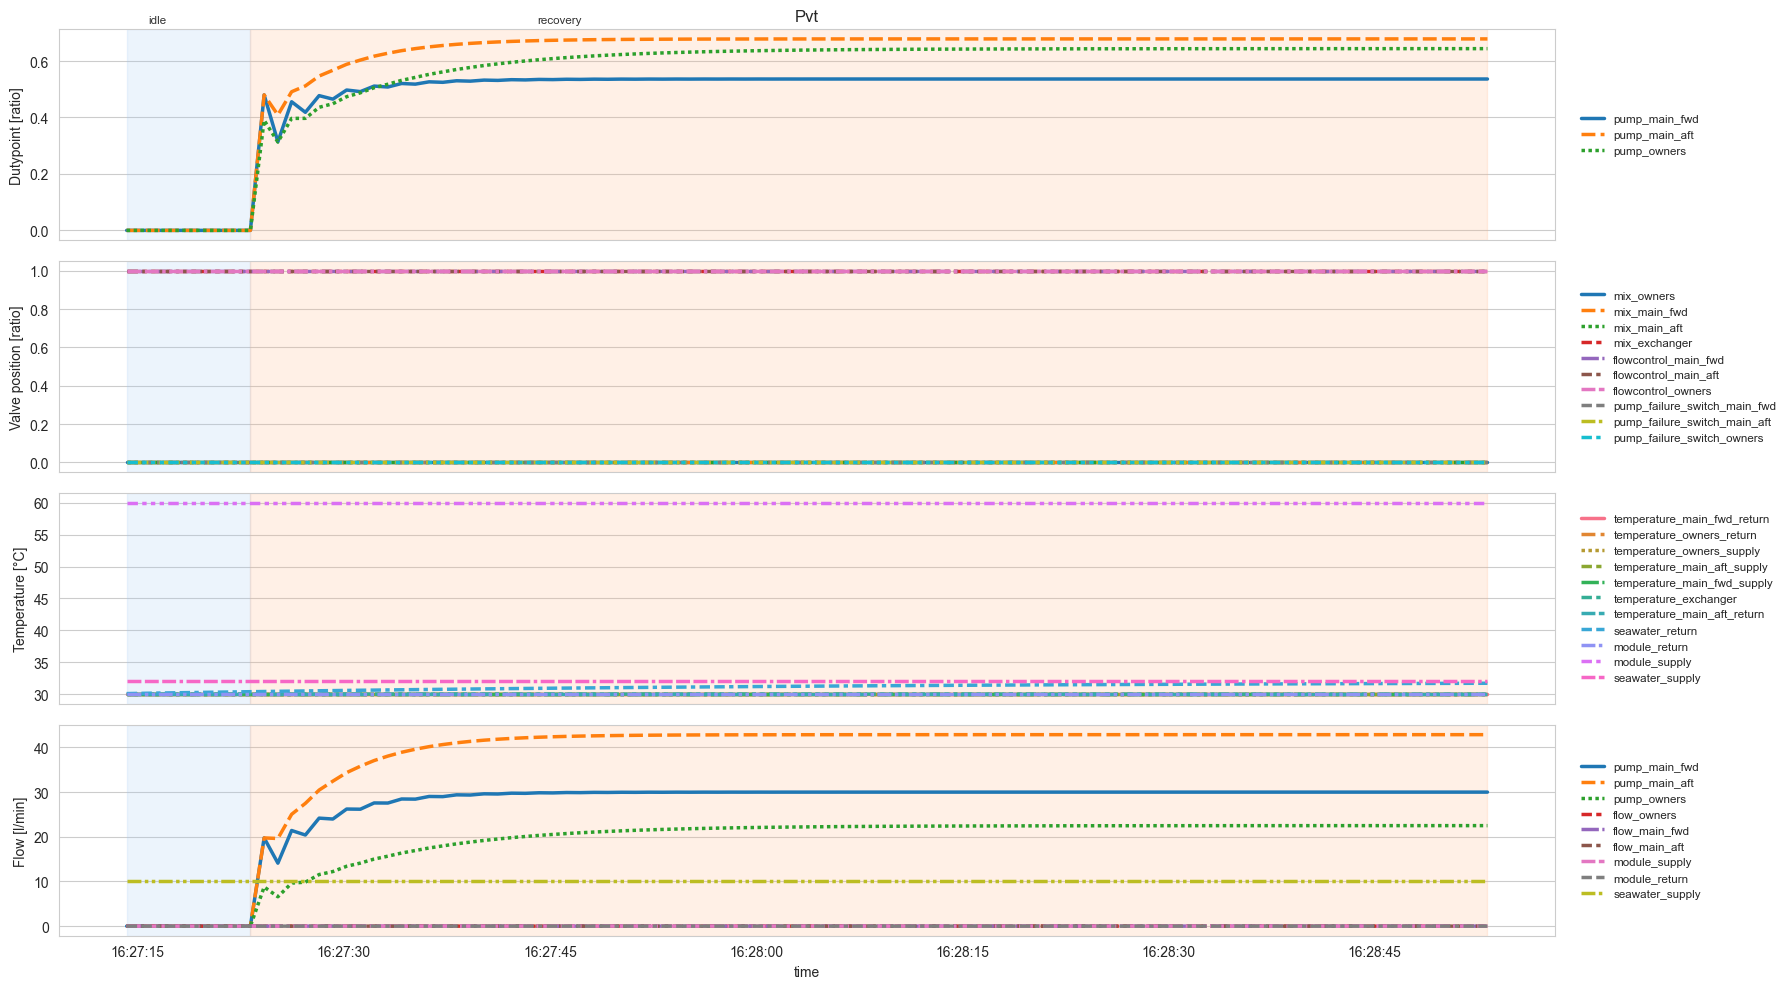

In [ ]:
from datetime import datetime, timedelta

from analysis.analysis_utils import plot_result
from thrs.control.modules.pvt import PvtControl, PvtParameters
from thrs.input_output.base import Stamped
from thrs.input_output.definitions.control import Valve
from thrs.input_output.definitions.simulation import (
    Boundary,
    HeatSource,
    TemperatureBoundary,
    ValvePosition,
)
from thrs.input_output.modules.pvt import (
    PvtSensorValues,
    PvtSimulationInputs,
    PvtSimulationOutputs,
)
from thrs.orchestration.collector import PolarsCollector
from thrs.orchestration.simulation import Simulation
from thrs.simulation.fmu import Fmu
from thrs.simulation.io_mapping import IoMapping
from thrs.simulation.models.fmu_paths import pvt_path

collector = PolarsCollector()

simulation = SimulatorModel(
    IoMapping(Fmu(pvt_path), PvtSensorValues, PvtSimulationOutputs),
    PvtSimulationInputs(
        pvt_main_fwd=HeatSource(heat_flow=Stamped.stamp(0.0)),
        pvt_main_aft=HeatSource(heat_flow=Stamped.stamp(0.0)),
        pvt_owners=HeatSource(heat_flow=Stamped.stamp(0.0)),
        pvt_pump_failure_switch_main_fwd=ValvePosition(
            position_rel=Stamped.stamp(Valve.CLOSED)
        ),
        pvt_pump_failure_switch_main_aft=ValvePosition(
            position_rel=Stamped.stamp(Valve.CLOSED)
        ),
        pvt_pump_failure_switch_owners=ValvePosition(
            position_rel=Stamped.stamp(Valve.CLOSED)
        ),
        pvt_module_supply=TemperatureBoundary(temperature=Stamped.stamp(60)),
        pvt_seawater_supply=Boundary(
            temperature=Stamped.stamp(32), flow=Stamped.stamp(10)
        ),
    ),
    datetime.now(),
    timedelta(seconds=1),
)
control = PvtControl(PvtParameters())


control_values = control.initial(simulation.time())
result = await simulation.tick(control_values)

# stabilize
for i in range(10):
    control_values = control.control(result.sensor_values, simulation.time())
    result = await simulation.tick(control_values)
    collector.collect(result.raw, control.mode, result.timestamp)

control.to_recovery()
for i in range(90):
    # this is problematic - need to run control to update the time..
    control._time += timedelta(seconds=1)
    control._control_pumps(result.sensor_values)
    control_values = control._current_values
    # control_values = control.control(result.sensor_values, simulation.time())
    result = await simulation.tick(control_values)
    collector.collect(result.raw, control.mode, result.timestamp)


plot_result(collector.result(), "plots/pvt_test.png")

In [4]:
# Heat dump test

In [ ]:
from datetime import datetime, timedelta

from tests.helpers.collector import PolarsCollector
from thrs.control.modules.pvt import PvtControl, PvtParameters
from thrs.input_output.base import Stamped
from thrs.input_output.definitions.control import Valve
from thrs.input_output.definitions.simulation import (
    Boundary,
    HeatSource,
    TemperatureBoundary,
    ValvePosition,
)
from thrs.input_output.modules.pvt import (
    PvtSensorValues,
    PvtSimulationInputs,
    PvtSimulationOutputs,
)
from thrs.orchestration.simulation import Simulation
from thrs.simulation.fmu import Fmu
from thrs.simulation.io_mapping import IoMapping
from thrs.simulation.models.fmu_paths import pvt_path

collector = PolarsCollector()

simulation = Simulation(
    IoMapping(Fmu(pvt_path), PvtSensorValues, PvtSimulationOutputs),
    PvtSimulationInputs(
        pvt_main_fwd=HeatSource(heat_flow=Stamped.stamp(0.0)),
        pvt_main_aft=HeatSource(heat_flow=Stamped.stamp(0.0)),
        pvt_owners=HeatSource(heat_flow=Stamped.stamp(0.0)),
        pvt_pump_failure_switch_main_fwd=ValvePosition(
            position_rel=Stamped.stamp(Valve.CLOSED)
        ),
        pvt_pump_failure_switch_main_aft=ValvePosition(
            position_rel=Stamped.stamp(Valve.CLOSED)
        ),
        pvt_pump_failure_switch_owners=ValvePosition(
            position_rel=Stamped.stamp(Valve.CLOSED)
        ),
        pvt_module_supply=TemperatureBoundary(temperature=Stamped.stamp(70)),
        pvt_seawater_supply=Boundary(
            temperature=Stamped.stamp(10), flow=Stamped.stamp(200)
        ),
    ),
    datetime.now(),
    timedelta(seconds=1),
)
control = PvtControl(PvtParameters())


control._current_values.pvt_pump_main_fwd.dutypoint.value = 1.0
control._current_values.pvt_pump_main_aft.dutypoint.value = 1.0
control._current_values.pvt_pump_owners.dutypoint.value = 1.0
control._current_values.pvt_pump_main_fwd.on.value = True
control._current_values.pvt_pump_main_aft.on.value = True
control._current_values.pvt_pump_owners.on.value = True
control._current_values.pvt_mix_main_fwd.setpoint.value = Valve.MIXING_A_TO_AB
control._current_values.pvt_mix_main_aft.setpoint.value = Valve.MIXING_A_TO_AB
control._current_values.pvt_mix_owners.setpoint.value = Valve.MIXING_A_TO_AB
control._current_values.pvt_mix_exchanger.setpoint.value = Valve.MIXING_A_TO_AB

result = await simulation.tick(control._current_values)

# Pre-heat PVT with hot supply water to skip time needed to warm up
while (
    result.simulation_outputs.pvt_module_return.temperature.value
    < control.parameters.mix_temperature_setpoint
):  # type: ignore
    control_values = control.control(result.sensor_values, simulation.time())
    control._current_values.pvt_pump_main_fwd.dutypoint.value = 1.0
    control._current_values.pvt_pump_main_aft.dutypoint.value = 1.0
    control._current_values.pvt_pump_owners.dutypoint.value = 1.0
    control._current_values.pvt_pump_main_fwd.on.value = True
    control._current_values.pvt_pump_main_aft.on.value = True
    control._current_values.pvt_pump_owners.on.value = True
    control_values.pvt_mix_main_fwd.setpoint.value = Valve.MIXING_A_TO_AB
    control_values.pvt_mix_main_aft.setpoint.value = Valve.MIXING_A_TO_AB
    control_values.pvt_mix_owners.setpoint.value = Valve.MIXING_A_TO_AB
    control_values.pvt_mix_exchanger.setpoint.value = Valve.MIXING_A_TO_AB

    result = await simulation.tick(control_values)
    collector.collect(result.raw, control.mode, result.timestamp)

print(result.timestamp)
control.to_recovery()
# pre-heat exchanger
for i in range(60):
    control_values = control.control(result.sensor_values, simulation.time())
    control_values.pvt_mix_main_fwd.setpoint.value = Valve.MIXING_A_TO_AB
    control_values.pvt_mix_main_aft.setpoint.value = Valve.MIXING_A_TO_AB
    control_values.pvt_mix_owners.setpoint.value = Valve.MIXING_A_TO_AB
    control_values.pvt_mix_exchanger.setpoint.value = Valve.MIXING_B_TO_AB
    result = await simulation.tick(control_values)
    collector.collect(result.raw, control.mode, result.timestamp)

print(result.timestamp)

for i in range(300):
    control_values = control.control(result.sensor_values, simulation.time())
    result = await simulation.tick(control_values)
    collector.collect(result.raw, control.mode, result.timestamp)

2025-09-17 12:00:35.479285
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 59.3641, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 60.8014, mxstep steps taken before reaching tout.
2025-09-17 12:01:35.479285
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 170.371, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 174.305, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 187.174, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 190.842, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 217.904, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 218.054, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t

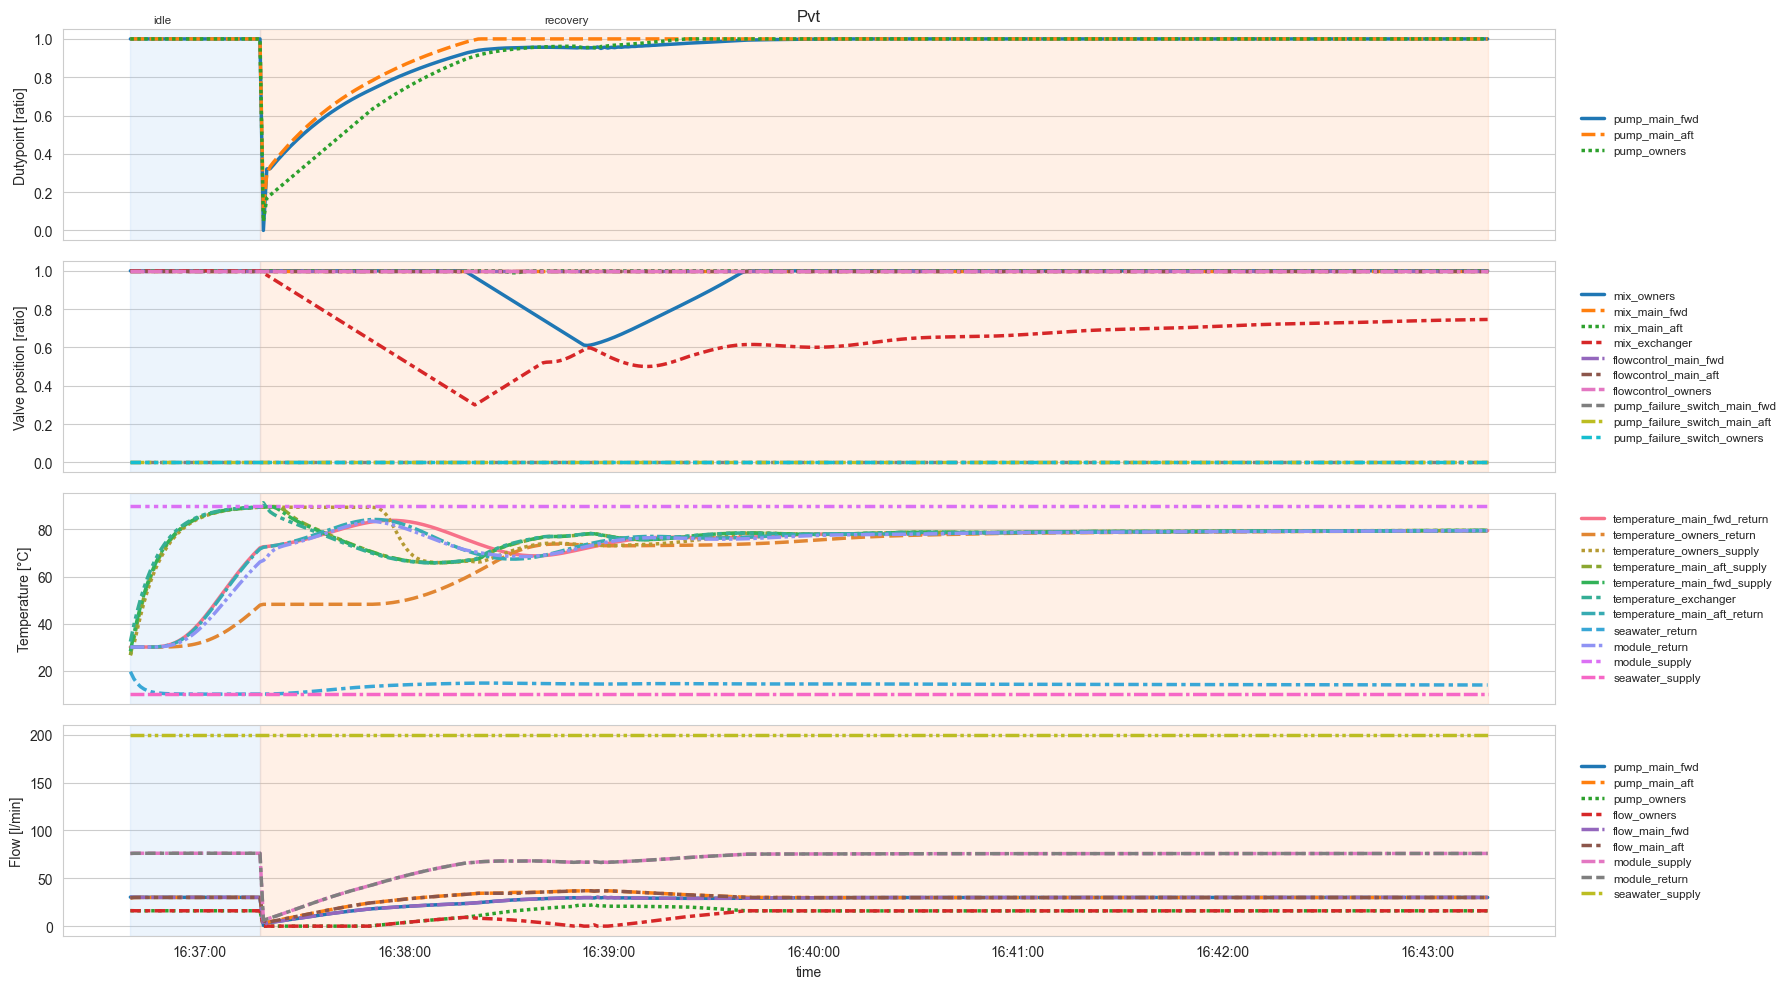

In [ ]:
from analysis.analysis_utils import plot_result

plot_result(collector.result(), "plots/pvt_test.png");